In [ ]:
TRAIN_LABELS = "/content/drive/MyDrive/Major_Project/Class20_yolo/test/images"
VAL_LABELS  = "/content/drive/MyDrive/Major_Project/Class20_yolo/test/labels"

!ls "$TRAIN_LABELS" | wc -l
!ls "$VAL_LABELS" | wc -l

3991
3991


In [ ]:
import yaml
from pathlib import Path

output_base = '/content/drive/MyDrive/Major_Project/Class20_yolo'  # ✅ updated
CLASS_NAMES = [1, 3, 4, 5, 7, 11, 13, 14, 19, 20,
               21, 22, 23, 24, 25, 28, 33, 34, 35, 40]

yaml_path = Path(output_base) / 'data.yaml'

data_yaml = {
    'path' : output_base,
    'train': 'train/images',
    'val'  : 'val/images',
    'test' : 'test/images',
    'nc'   : len(CLASS_NAMES),
    'names': [str(c) for c in CLASS_NAMES],
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'📝 data.yaml written!\n')
with open(yaml_path) as f:
    print(f.read())

📝 data.yaml written!

path: /content/drive/MyDrive/Major_Project/Class20_yolo
train: train/images
val: val/images
test: test/images
nc: 20
names:
- '1'
- '3'
- '4'
- '5'
- '7'
- '11'
- '13'
- '14'
- '19'
- '20'
- '21'
- '22'
- '23'
- '24'
- '25'
- '28'
- '33'
- '34'
- '35'
- '40'



In [ ]:
# ===================== INSTALL & IMPORT =====================
!pip install ultralytics -q


from ultralytics import YOLO

print("✅ YOLO imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO imported successfully


In [ ]:
OUT = '/content/drive/MyDrive/Major_Project/Class20_yolo'


# ===================== TRAIN MODEL =====================
model = YOLO("yolov8n.pt")

print("\n" + "="*80)
print("🚀 STARTING TRAINING - Metrics will be printed after each epoch")
print("="*80 + "\n")

results = model.train(
    data=f"{OUT}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project=OUT,
    name="Class20_10epoch",
    plots=True,
    save=True,
    verbose=True  # This prints metrics after each epoch
)

print("\n✅ Training completed!")


🚀 STARTING TRAINING - Metrics will be printed after each epoch

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Major_Project/Class20_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Class20_10epoch, nb

In [ ]:
from ultralytics import YOLO

# Load your saved .pt model from Drive
model = YOLO('/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.pt')  # update path

# Export to ONNX
model.export(format='onnx')
print("✅ ONNX export done!")

# Export to TFLite
model.export(format='tflite')
print("✅ TFLite export done!")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.30GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 209ms
Prepared 4 packages in 9.53s
Installed 4 packages in 314ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 10.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export 

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 12.2s, saved as '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.onnx' (11.7 MB)

Export complete (12.7s)
Results saved to /content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/Major_Project/Class20_yolo/data.yaml  
Visualize:       https://netron.app
✅ ONNX export done!
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.30GHz)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.pt' with input shape (1, 3, 640, 640

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 2.0s, saved as '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.onnx' (11.8 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 33.1files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 24, 8400), dtype=tf.float32, name=None)
Captures:
  132038120567632: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  132038120566096: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  132038120566864: TensorSpec(shape=(16,), dtype=tf.float32, na

In [ ]:
# ===================== INSTALL & IMPORT =====================
!pip install ultralytics -q


from ultralytics import YOLO

print("✅ YOLO imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO imported successfully


In [ ]:
import os
from ultralytics import YOLO
from google.colab import drive

# ===================== MOUNT DRIVE =====================
drive.mount('/content/drive')

OUT = '/content/drive/MyDrive/Major_Project/Class20_yolo'
EPOCHS = 50  # Set your total target epochs here
RUN_NAME = "Class20_50epoch"
CHECKPOINT_PATH = f"{OUT}/{RUN_NAME}/weights/last.pt"

# ===================== LOAD MODEL =====================
# Resume from last checkpoint if it exists, else start fresh
if os.path.exists(CHECKPOINT_PATH):
    print(f"\n✅ Checkpoint found! Resuming from: {CHECKPOINT_PATH}")
    model = YOLO(CHECKPOINT_PATH)
else:
    print("\n🚀 No checkpoint found. Starting fresh training...")
    model = YOLO("yolov8n.pt")

print("\n" + "="*80)
print("🚀 STARTING TRAINING - Metrics will be printed after each epoch")
print("="*80 + "\n")

# ===================== TRAIN MODEL =====================
results = model.train(
    data=f"{OUT}/data.yaml",
    epochs=EPOCHS,
    imgsz=640,
    batch=16,
    project=OUT,
    name=RUN_NAME,
    plots=True,
    save=True,
    save_period=5,       # 💾 Save checkpoint every 5 epochs
    resume=os.path.exists(CHECKPOINT_PATH),  # Auto-resume if checkpoint exists
    verbose=True,
    exist_ok=True        # Prevents creating duplicate folders like run2, run3...
)

print("\n✅ Training completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Checkpoint found! Resuming from: /content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/last.pt

🚀 STARTING TRAINING - Metrics will be printed after each epoch

Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0]
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Major_Project/Class20_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exis

In [3]:
from ultralytics import YOLO

# Load your saved .pt model from Drive
model = YOLO('/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.pt')  # update path

# Export to ONNX
model.export(format='onnx')
print("✅ ONNX export done!")

# Export to TFLite
model.export(format='tflite')
print("✅ TFLite export done!")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (17.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 398ms
Prepared 4 packages in 2.39s
Installed 4 packages in 342ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 6.6s, saved as '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.onnx' (11.7 MB)

Export complete (9.0s)
Results saved to /content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/Major_Project/Class20_yolo/data.yaml  
Visualize:       https://netron.app
✅ ONNX export done!
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.pt' with input shape (1, 3, 640, 640) BC

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.6s, saved as '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best.onnx' (11.8 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 43.0files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_50epoch/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 24, 8400), dtype=tf.float32, name=None)
Captures:
  138665900125520: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138665900125136: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  138665900122256: TensorSpec(shape=(16,), dtype=tf.float32, na

In [2]:
# ===================== INSTALL & IMPORT =====================
!pip install ultralytics -q


from ultralytics import YOLO

print("✅ YOLO imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO imported successfully


🎯 YOLO MODEL - COMPLETE ANALYSIS WITH 10 KEY METRICS

📂 Configuration:
   Training Results: /content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch
   Dataset:          /content/drive/MyDrive/Major_Project/Class20_yolo
   Test Output:      /content/drive/MyDrive/Major_Project/Class20_yolo/test_analysis_resultsinplot
   Model Weights:    /content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.pt

📊 PART 1: TRAINING HISTORY (Epoch-by-Epoch Metrics)

Training Metrics for All Epochs:
--------------------------------------------------------------------------------------------------------------
Epoch    Train Loss      Val Loss        Val mAP50       Val mAP50-95    Precision       Recall         
--------------------------------------------------------------------------------------------------------------
1        0.7512          0.5907          0.8856          0.7628          0.8102          0.9069         
2        0.5762          0.4804          0.9377   

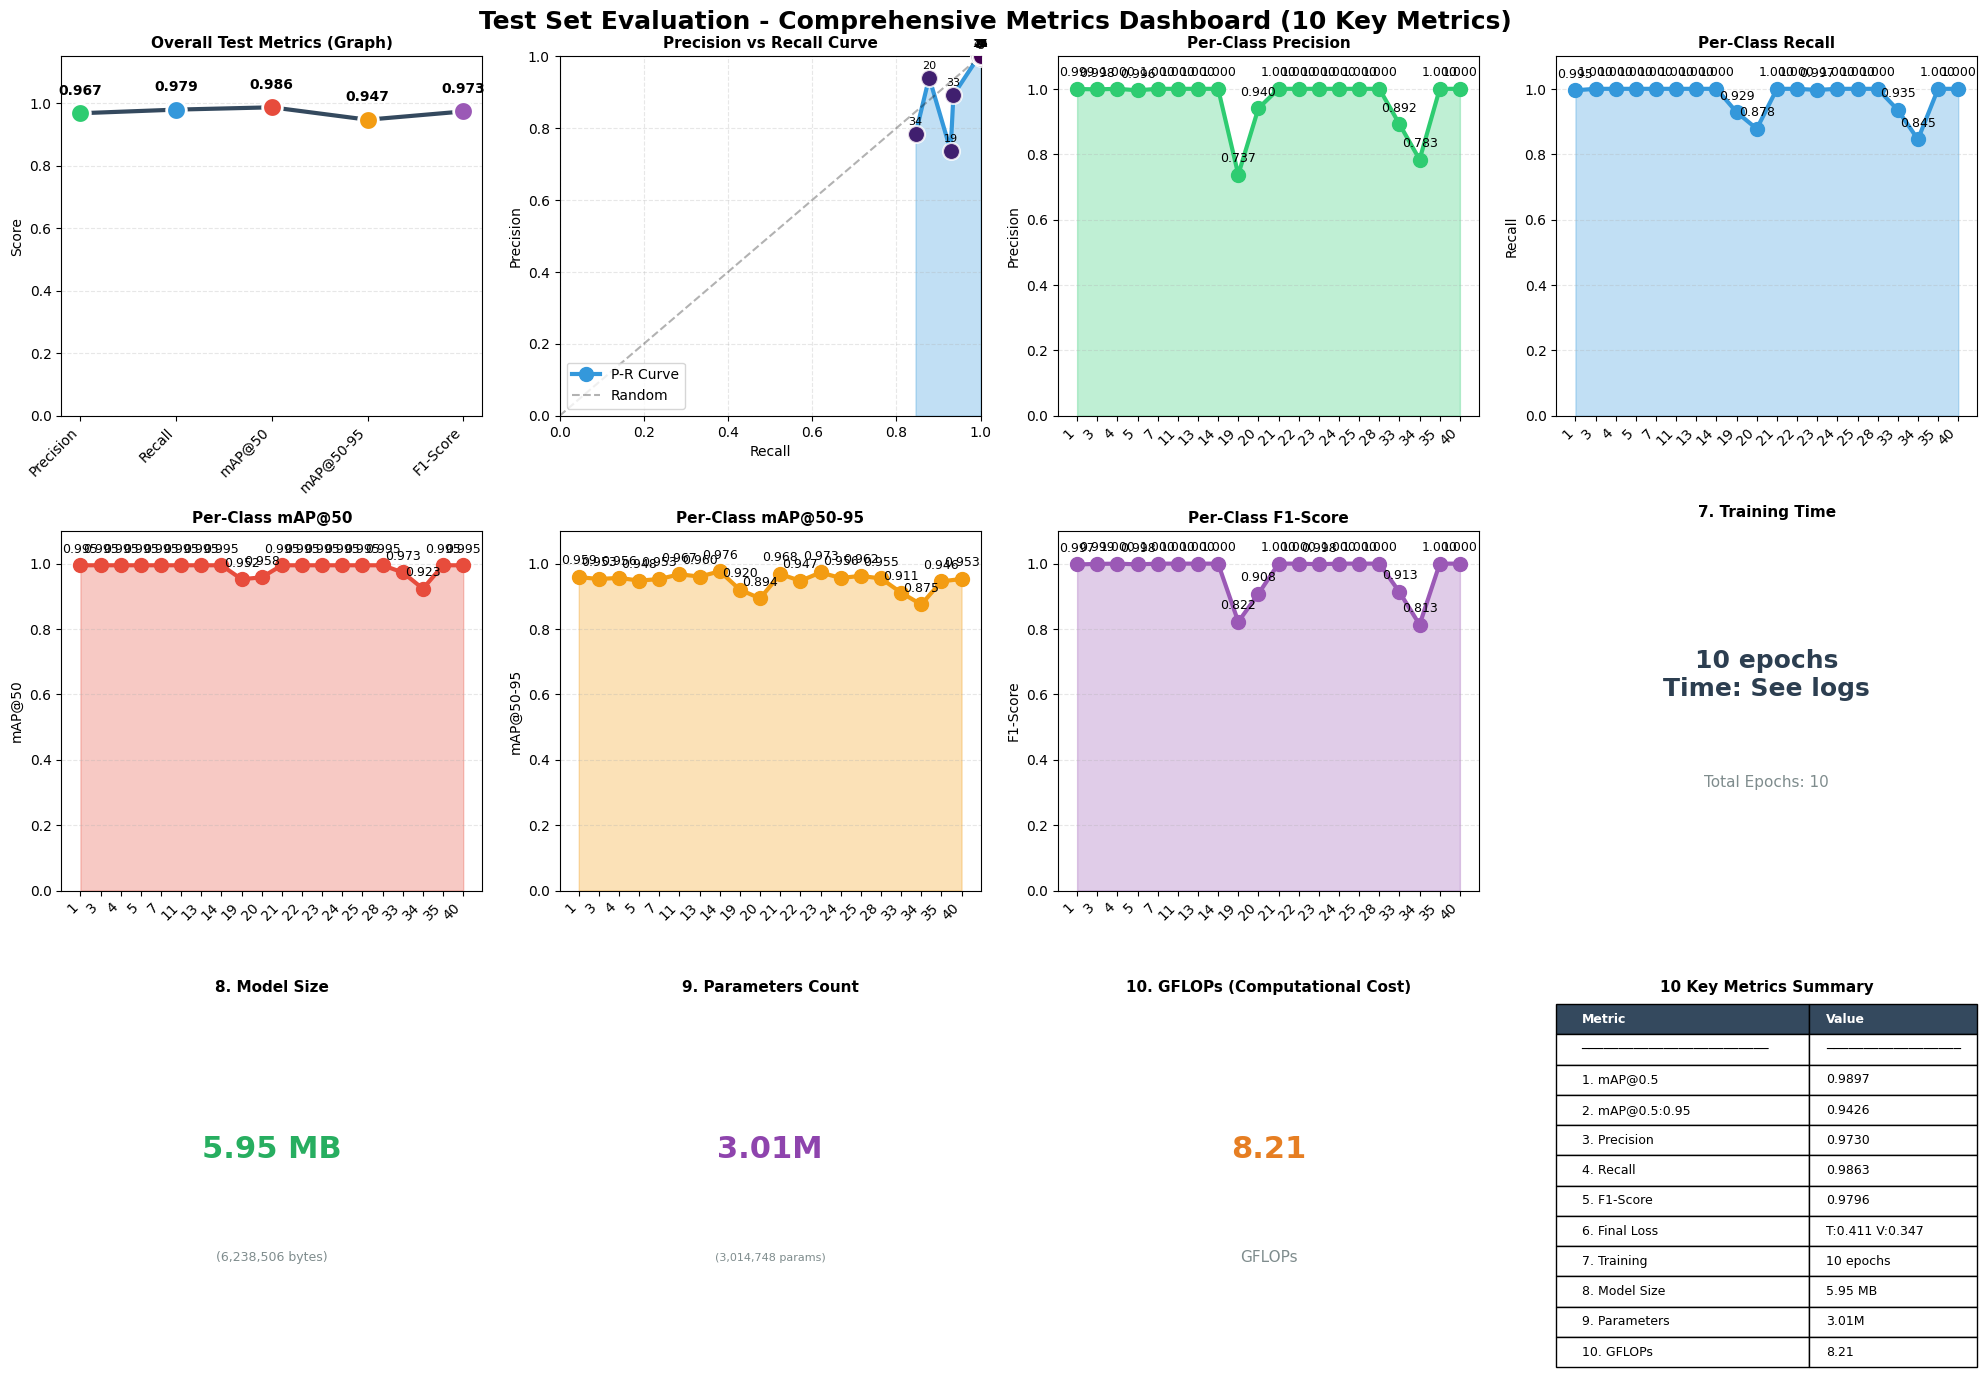

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns
import os

# ===================== CONFIGURATION =====================
# Path 1: Where your training results are saved (contains weights/ folder and results.csv)
TRAINING_OUTPUT_DIR = "/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch"
# Path 2: Where your dataset folder is
DATASET_PATH = "/content/drive/MyDrive/Major_Project/Class20_yolo"
# Path 3: Where to save test analysis results
TEST_OUTPUT_DIR = "/content/drive/MyDrive/Major_Project/Class20_yolo/test_analysis_resultsinplot"

# Create output directory
Path(TEST_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Derived paths (automatically constructed from above)
RESULTS_CSV = "/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/results.csv"
BEST_MODEL_PATH = "/content/drive/MyDrive/Major_Project/Class20_yolo/Class20_10epoch/weights/best.pt"
DATA_YAML = "/content/drive/MyDrive/Major_Project/Class20_yolo/data.yaml"

print("="*100)
print("🎯 YOLO MODEL - COMPLETE ANALYSIS WITH 10 KEY METRICS")
print("="*100)
print(f"\n📂 Configuration:")
print(f"   Training Results: {TRAINING_OUTPUT_DIR}")
print(f"   Dataset:          {DATASET_PATH}")
print(f"   Test Output:      {TEST_OUTPUT_DIR}")
print(f"   Model Weights:    {BEST_MODEL_PATH}")
print("="*100)

# ===================== INITIALIZE ALL VARIABLES =====================
# Initialize to None to avoid undefined variable errors
epochs = None
train_box_loss = None
val_box_loss = None
map50_history = None
map5095_history = None
precision_history = None
recall_history = None
f1_history = None
metric_1_map50 = None
metric_2_map5095 = None
metric_3_precision = None
metric_4_recall = None
metric_5_f1_score = None
training_success = False

# ===================== PART 1: TRAINING HISTORY ANALYSIS =====================
print("\n" + "="*100)
print("📊 PART 1: TRAINING HISTORY (Epoch-by-Epoch Metrics)")
print("="*100 + "\n")

try:
    # Load training results
    df_train = pd.read_csv(RESULTS_CSV)
    df_train.columns = df_train.columns.str.strip()

    print("Training Metrics for All Epochs:")
    print("-" * 110)
    print("{:<8} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
        "Epoch", "Train Loss", "Val Loss", "Val mAP50", "Val mAP50-95", "Precision", "Recall"
    ))
    print("-" * 110)

    for idx, row in df_train.iterrows():
        print("{:<8} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
            int(row['epoch']),
            row['train/box_loss'],
            row['val/box_loss'],
            row['metrics/mAP50(B)'],
            row['metrics/mAP50-95(B)'],
            row['metrics/precision(B)'],
            row['metrics/recall(B)']
        ))

    print("-" * 110)
    print(f"✅ Training completed with {len(df_train)} epochs")

    # Extract data for metrics calculations
    epochs = df_train['epoch'].values
    train_box_loss = df_train['train/box_loss'].values
    val_box_loss = df_train['val/box_loss'].values
    map50_history = df_train['metrics/mAP50(B)'].values
    map5095_history = df_train['metrics/mAP50-95(B)'].values
    precision_history = df_train['metrics/precision(B)'].values
    recall_history = df_train['metrics/recall(B)'].values
    f1_history = 2 * (precision_history * recall_history) / (precision_history + recall_history + 1e-6)

    # Final epoch metrics
    final_epoch = df_train.iloc[-1]
    metric_1_map50 = float(final_epoch['metrics/mAP50(B)'])
    metric_2_map5095 = float(final_epoch['metrics/mAP50-95(B)'])
    metric_3_precision = float(final_epoch['metrics/precision(B)'])
    metric_4_recall = float(final_epoch['metrics/recall(B)'])
    metric_5_f1_score = 2 * (metric_3_precision * metric_4_recall) / (metric_3_precision + metric_4_recall + 1e-6)

    training_success = True

    # Plot training history with GRAPH PLOTS
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History - Graph Analysis with Smooth Curves', fontsize=16, fontweight='bold')

    # 1. Losses - Line plot with fill
    ax1 = axes[0, 0]
    ax1.plot(epochs, train_box_loss, 'o-', label='Train Loss', linewidth=2.5, markersize=6, color='#e74c3c')
    ax1.plot(epochs, val_box_loss, 's-', label='Val Loss', linewidth=2.5, markersize=6, color='#3498db')
    ax1.fill_between(epochs, train_box_loss, alpha=0.2, color='#e74c3c')
    ax1.fill_between(epochs, val_box_loss, alpha=0.2, color='#3498db')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss', fontsize=11)
    ax1.set_title('6. Loss Curves (Training & Validation)', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, linestyle='--')

    # 2. mAP50 - Line plot with fill
    ax2 = axes[0, 1]
    ax2.plot(epochs, map50_history, 'o-', color='#2ecc71', linewidth=3, markersize=8)
    ax2.fill_between(epochs, map50_history, alpha=0.3, color='#2ecc71')
    ax2.axhline(y=metric_1_map50, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_1_map50:.4f}')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('mAP@0.5', fontsize=11)
    ax2.set_title('1. mAP@0.5 Progress', fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_ylim([0, 1])

    # 3. mAP50-95 - Line plot with fill
    ax3 = axes[0, 2]
    ax3.plot(epochs, map5095_history, 'o-', color='#f39c12', linewidth=3, markersize=8)
    ax3.fill_between(epochs, map5095_history, alpha=0.3, color='#f39c12')
    ax3.axhline(y=metric_2_map5095, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_2_map5095:.4f}')
    ax3.set_xlabel('Epoch', fontsize=11)
    ax3.set_ylabel('mAP@0.5:0.95', fontsize=11)
    ax3.set_title('2. mAP@0.5:0.95 Progress', fontweight='bold')
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_ylim([0, 1])

    # 4. Precision - Line plot with fill
    ax4 = axes[1, 0]
    ax4.plot(epochs, precision_history, 'o-', color='#9b59b6', linewidth=3, markersize=8)
    ax4.fill_between(epochs, precision_history, alpha=0.3, color='#9b59b6')
    ax4.axhline(y=metric_3_precision, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_3_precision:.4f}')
    ax4.set_xlabel('Epoch', fontsize=11)
    ax4.set_ylabel('Precision', fontsize=11)
    ax4.set_title('3. Precision Progress', fontweight='bold')
    ax4.legend(loc='lower right')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_ylim([0, 1])

    # 5. Recall - Line plot with fill
    ax5 = axes[1, 1]
    ax5.plot(epochs, recall_history, 'o-', color='#1abc9c', linewidth=3, markersize=8)
    ax5.fill_between(epochs, recall_history, alpha=0.3, color='#1abc9c')
    ax5.axhline(y=metric_4_recall, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_4_recall:.4f}')
    ax5.set_xlabel('Epoch', fontsize=11)
    ax5.set_ylabel('Recall', fontsize=11)
    ax5.set_title('4. Recall Progress', fontweight='bold')
    ax5.legend(loc='lower right')
    ax5.grid(True, alpha=0.3, linestyle='--')
    ax5.set_ylim([0, 1])

    # 6. F1-Score - Line plot with fill
    ax6 = axes[1, 2]
    ax6.plot(epochs, f1_history, 'o-', color='#e74c3c', linewidth=3, markersize=8)
    ax6.fill_between(epochs, f1_history, alpha=0.3, color='#e74c3c')
    ax6.axhline(y=metric_5_f1_score, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label=f'Final: {metric_5_f1_score:.4f}')
    ax6.set_xlabel('Epoch', fontsize=11)
    ax6.set_ylabel('F1-Score', fontsize=11)
    ax6.set_title('5. F1-Score Progress', fontweight='bold')
    ax6.legend(loc='lower right')
    ax6.grid(True, alpha=0.3, linestyle='--')
    ax6.set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(f'{TEST_OUTPUT_DIR}/training_history_graphs.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Training history graph saved: {TEST_OUTPUT_DIR}/training_history_graphs.png")

except Exception as e:
    print(f"⚠️ Error loading training history: {e}")
    print("⚠️ Will use test results for metrics 1-5")
    training_success = False

# ===================== LOAD MODEL & GET INFO =====================
print("\n📦 Loading model and extracting model information...")
model = YOLO(BEST_MODEL_PATH)

# Get model info for metrics 8, 9, 10
try:
    model_info = model.info(verbose=False)
except:
    model_info = None

# Metric 7: Training Time (estimate from epochs)
training_time_hours = None
training_time_minutes = None

# Metric 8: Model Size (MB)
try:
    model_size_bytes = os.path.getsize(BEST_MODEL_PATH)
    metric_8_model_size_mb = model_size_bytes / (1024 * 1024)
except:
    model_size_bytes = 0
    metric_8_model_size_mb = 0.0

# Metric 9: Parameters Count
metric_9_parameters = None
if model_info and isinstance(model_info, tuple):
    metric_9_parameters = model_info[0]

if metric_9_parameters is None:
    try:
        total_params = sum(p.numel() for p in model.model.parameters())
        metric_9_parameters = total_params
    except:
        metric_9_parameters = None

# Metric 10: GFLOPs
metric_10_gflops = None
try:
    from ultralytics.utils.torch_utils import get_flops
    metric_10_gflops = get_flops(model.model)
except:
    info = model.info(verbose=False)
    metric_10_gflops = info[1]

# ===================== PART 2: TEST SET EVALUATION =====================
print("\n" + "="*100)
print("🧪 PART 2: TEST SET EVALUATION (Comprehensive Analysis)")
print("="*100 + "\n")

# Run evaluation on test set
print(f"🔍 Running evaluation on test dataset...")
test_results = model.val(
    data=DATA_YAML,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True,
    project=TEST_OUTPUT_DIR,
    name='test_evaluation'
)

print("\n✅ Test evaluation completed!")

# ===================== EXTRACT TEST METRICS =====================
print("\n📊 Extracting test metrics...")

# Overall metrics
metrics = {
    'Precision': test_results.box.mp,
    'Recall': test_results.box.mr,
    'mAP@50': test_results.box.map50,
    'mAP@50-95': test_results.box.map,
    'F1-Score': 2 * (test_results.box.mp * test_results.box.mr) / (test_results.box.mp + test_results.box.mr + 1e-6),
}

# If training metrics weren't loaded successfully, use test metrics
if not training_success or metric_1_map50 is None:
    print("⚠️ Using test set metrics for metrics 1-5")
    metric_1_map50 = float(test_results.box.map50)
    metric_2_map5095 = float(test_results.box.map)
    metric_3_precision = float(test_results.box.mp)
    metric_4_recall = float(test_results.box.mr)
    metric_5_f1_score = float(metrics['F1-Score'])

# Per-class metrics
per_class_metrics = {
    'Class': list(test_results.names.values()),
    'Precision': test_results.box.p.tolist() if hasattr(test_results.box, 'p') else [],
    'Recall': test_results.box.r.tolist() if hasattr(test_results.box, 'r') else [],
    'AP@50': test_results.box.ap50.tolist() if hasattr(test_results.box, 'ap50') else [],
    'AP@50-95': test_results.box.ap.tolist() if hasattr(test_results.box, 'ap') else [],
}

print("\n" + "="*100)
print("🎯 FINAL TEST SET RESULTS (Overall Metrics)")
print("="*100)
for metric_name, value in metrics.items():
    print(f"{metric_name:20s}: {value:.4f}")
print("="*100)

# ===================== DISPLAY ALL 10 METRICS =====================
print("\n" + "="*100)
print("📈 10 KEY METRICS - FINAL RESULTS")
print("="*100)
print(f"\n{'Metric':<30} {'Value':<20}")
print("-" * 50)
print(f"{'1. mAP@0.5':<30} {metric_1_map50:.4f}")
print(f"{'2. mAP@0.5:0.95':<30} {metric_2_map5095:.4f}")
print(f"{'3. Precision':<30} {metric_3_precision:.4f}")
print(f"{'4. Recall':<30} {metric_4_recall:.4f}")
print(f"{'5. F1-Score':<30} {metric_5_f1_score:.4f}")

if train_box_loss is not None and len(train_box_loss) > 0:
    print(f"{'6. Loss Curves':<30} {'Train: {:.4f}, Val: {:.4f}'.format(train_box_loss[-1], val_box_loss[-1])}")
else:
    print(f"{'6. Loss Curves':<30} {'See training logs'}")

if training_time_hours:
    print(f"{'7. Training Time':<30} {training_time_hours:.2f} hours ({training_time_minutes:.1f} min)")
elif epochs is not None and len(epochs) > 0:
    print(f"{'7. Training Time':<30} {len(epochs)} epochs (see logs)")
else:
    print(f"{'7. Training Time':<30} {'See training logs'}")

print(f"{'8. Model Size (MB)':<30} {metric_8_model_size_mb:.2f} MB")

if metric_9_parameters:
    print(f"{'9. Parameters Count':<30} {metric_9_parameters:,} ({metric_9_parameters/1e6:.2f}M)")
else:
    print(f"{'9. Parameters Count':<30} {'Calculating...'}")

if metric_10_gflops:
    print(f"{'10. GFLOPs':<30} {metric_10_gflops:.2f}")
else:
    print(f"{'10. GFLOPs':<30} {'Calculating...'}")
print("="*100)

# ===================== CREATE COMPREHENSIVE VISUALIZATIONS WITH GRAPHS =====================
print("\n📊 Creating comprehensive test visualizations with graph plots...")

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Test Set Evaluation - Comprehensive Metrics Dashboard (10 Key Metrics)',
             fontsize=18, fontweight='bold')

# 1. Overall Metrics - LINE PLOT with Markers
ax1 = plt.subplot(3, 4, 1)
metric_names = list(metrics.keys())
metric_values = list(metrics.values())
x_pos = np.arange(len(metric_names))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

ax1.plot(x_pos, metric_values, 'o-', linewidth=3, markersize=12, color='#34495e')
for i, (val, color) in enumerate(zip(metric_values, colors)):
    ax1.scatter(i, val, s=200, color=color, zorder=5, edgecolors='white', linewidths=2)
    ax1.text(i, val + 0.05, f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(metric_names, rotation=45, ha='right')
ax1.set_ylim([0, 1.15])
ax1.set_title('Overall Test Metrics (Graph)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Score')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# 2. Precision-Recall Curve
ax2 = plt.subplot(3, 4, 2)
if len(per_class_metrics['Precision']) > 0:
    precisions = np.array(per_class_metrics['Precision'])
    recalls = np.array(per_class_metrics['Recall'])
    classes = per_class_metrics['Class']

    # Sort by recall for smooth curve
    sort_idx = np.argsort(recalls)
    recalls_sorted = recalls[sort_idx]
    precisions_sorted = precisions[sort_idx]

    ax2.plot(recalls_sorted, precisions_sorted, 'o-', linewidth=3, markersize=10, color='#3498db', label='P-R Curve')
    ax2.fill_between(recalls_sorted, precisions_sorted, alpha=0.3, color='#3498db')

    for i, class_name in enumerate(classes):
        ax2.scatter(recalls[i], precisions[i], s=150, alpha=0.8, c=[i], cmap='viridis',
                   edgecolors='white', linewidths=1.5, zorder=5)
        ax2.annotate(class_name, (recalls[i], precisions[i]), fontsize=8, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5, label='Random')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision vs Recall Curve', fontweight='bold', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])
    ax2.legend(loc='lower left')

# 3. Per-Class Precision - LINE GRAPH
ax3 = plt.subplot(3, 4, 3)
if len(per_class_metrics['Precision']) > 0:
    classes = per_class_metrics['Class']
    precisions = per_class_metrics['Precision']
    x_pos_class = np.arange(len(classes))

    ax3.plot(x_pos_class, precisions, 'o-', linewidth=3, markersize=10, color='#2ecc71')
    ax3.fill_between(x_pos_class, precisions, alpha=0.3, color='#2ecc71')

    for i, val in enumerate(precisions):
        ax3.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax3.set_xticks(x_pos_class)
    ax3.set_xticklabels(classes, rotation=45, ha='right')
    ax3.set_ylim([0, 1.1])
    ax3.set_title('Per-Class Precision', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Precision')
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# 4. Per-Class Recall - LINE GRAPH
ax4 = plt.subplot(3, 4, 4)
if len(per_class_metrics['Recall']) > 0:
    recalls_pc = per_class_metrics['Recall']

    ax4.plot(x_pos_class, recalls_pc, 'o-', linewidth=3, markersize=10, color='#3498db')
    ax4.fill_between(x_pos_class, recalls_pc, alpha=0.3, color='#3498db')

    for i, val in enumerate(recalls_pc):
        ax4.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax4.set_xticks(x_pos_class)
    ax4.set_xticklabels(classes, rotation=45, ha='right')
    ax4.set_ylim([0, 1.1])
    ax4.set_title('Per-Class Recall', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Recall')
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# 5. Per-Class mAP@50 - LINE GRAPH
ax5 = plt.subplot(3, 4, 5)
if len(per_class_metrics['AP@50']) > 0:
    ap50_values = per_class_metrics['AP@50']

    ax5.plot(x_pos_class, ap50_values, 'o-', linewidth=3, markersize=10, color='#e74c3c')
    ax5.fill_between(x_pos_class, ap50_values, alpha=0.3, color='#e74c3c')

    for i, val in enumerate(ap50_values):
        ax5.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax5.set_xticks(x_pos_class)
    ax5.set_xticklabels(classes, rotation=45, ha='right')
    ax5.set_ylim([0, 1.1])
    ax5.set_title('Per-Class mAP@50', fontweight='bold', fontsize=11)
    ax5.set_ylabel('mAP@50')
    ax5.grid(True, alpha=0.3, linestyle='--', axis='y')

# 6. Per-Class mAP@50-95 - LINE GRAPH
ax6 = plt.subplot(3, 4, 6)
if len(per_class_metrics['AP@50-95']) > 0:
    ap_values = per_class_metrics['AP@50-95']

    ax6.plot(x_pos_class, ap_values, 'o-', linewidth=3, markersize=10, color='#f39c12')
    ax6.fill_between(x_pos_class, ap_values, alpha=0.3, color='#f39c12')

    for i, val in enumerate(ap_values):
        ax6.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax6.set_xticks(x_pos_class)
    ax6.set_xticklabels(classes, rotation=45, ha='right')
    ax6.set_ylim([0, 1.1])
    ax6.set_title('Per-Class mAP@50-95', fontweight='bold', fontsize=11)
    ax6.set_ylabel('mAP@50-95')
    ax6.grid(True, alpha=0.3, linestyle='--', axis='y')

# 7. Per-Class F1-Score - LINE GRAPH
ax7 = plt.subplot(3, 4, 7)
if len(per_class_metrics['Precision']) > 0 and len(per_class_metrics['Recall']) > 0:
    f1_scores = 2 * (np.array(per_class_metrics['Precision']) * np.array(per_class_metrics['Recall'])) / \
                (np.array(per_class_metrics['Precision']) + np.array(per_class_metrics['Recall']) + 1e-6)

    ax7.plot(x_pos_class, f1_scores, 'o-', linewidth=3, markersize=10, color='#9b59b6')
    ax7.fill_between(x_pos_class, f1_scores, alpha=0.3, color='#9b59b6')

    for i, val in enumerate(f1_scores):
        ax7.text(i, val + 0.03, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax7.set_xticks(x_pos_class)
    ax7.set_xticklabels(classes, rotation=45, ha='right')
    ax7.set_ylim([0, 1.1])
    ax7.set_title('Per-Class F1-Score', fontweight='bold', fontsize=11)
    ax7.set_ylabel('F1-Score')
    ax7.grid(True, alpha=0.3, linestyle='--', axis='y')

# 8. Training Time Display
ax8 = plt.subplot(3, 4, 8)
ax8.axis('off')
time_text = ""
if training_time_hours:
    time_text = f"{training_time_hours:.2f} hours\n({training_time_minutes:.1f} min)"
elif epochs is not None and len(epochs) > 0:
    time_text = f"{len(epochs)} epochs\nTime: See logs"
else:
    time_text = "See training logs"
ax8.text(0.5, 0.6, time_text, ha='center', va='center', fontsize=18, fontweight='bold', color='#2c3e50')
if epochs is not None and len(epochs) > 0:
    ax8.text(0.5, 0.3, f'Total Epochs: {len(epochs)}', ha='center', va='center', fontsize=11, color='#7f8c8d')
ax8.set_title('7. Training Time', fontweight='bold', fontsize=11, pad=10)

# 9. Model Size Display
ax9 = plt.subplot(3, 4, 9)
ax9.axis('off')
ax9.text(0.5, 0.6, f'{metric_8_model_size_mb:.2f} MB', ha='center', va='center',
         fontsize=22, fontweight='bold', color='#27ae60')
ax9.text(0.5, 0.3, f'({model_size_bytes:,} bytes)', ha='center', va='center',
         fontsize=9, color='#7f8c8d')
ax9.set_title('8. Model Size', fontweight='bold', fontsize=11, pad=10)

# 10. Parameters Count Display
ax10 = plt.subplot(3, 4, 10)
ax10.axis('off')
if metric_9_parameters:
    params_millions = metric_9_parameters / 1e6
    ax10.text(0.5, 0.6, f'{params_millions:.2f}M', ha='center', va='center',
              fontsize=22, fontweight='bold', color='#8e44ad')
    ax10.text(0.5, 0.3, f'({metric_9_parameters:,} params)', ha='center', va='center',
              fontsize=8, color='#7f8c8d')
else:
    ax10.text(0.5, 0.5, 'Calculating...', ha='center', va='center', fontsize=14, color='#7f8c8d')
ax10.set_title('9. Parameters Count', fontweight='bold', fontsize=11, pad=10)

# 11. GFLOPs Display
ax11 = plt.subplot(3, 4, 11)
ax11.axis('off')
if metric_10_gflops:
    ax11.text(0.5, 0.6, f'{metric_10_gflops:.2f}', ha='center', va='center',
              fontsize=22, fontweight='bold', color='#e67e22')
    ax11.text(0.5, 0.3, 'GFLOPs', ha='center', va='center', fontsize=11, color='#7f8c8d')
else:
    ax11.text(0.5, 0.5, 'Calculating...', ha='center', va='center', fontsize=14, color='#7f8c8d')
ax11.set_title('10. GFLOPs (Computational Cost)', fontweight='bold', fontsize=11, pad=10)

# 12. Summary Table with ALL 10 METRICS
ax12 = plt.subplot(3, 4, 12)
ax12.axis('off')

summary_data = [
    ['Metric', 'Value'],
    ['─' * 25, '─' * 18],
    ['1. mAP@0.5', f'{metric_1_map50:.4f}'],
    ['2. mAP@0.5:0.95', f'{metric_2_map5095:.4f}'],
    ['3. Precision', f'{metric_3_precision:.4f}'],
    ['4. Recall', f'{metric_4_recall:.4f}'],
    ['5. F1-Score', f'{metric_5_f1_score:.4f}'],
]

if train_box_loss is not None and len(train_box_loss) > 0:
    summary_data.append(['6. Final Loss', f'T:{train_box_loss[-1]:.3f} V:{val_box_loss[-1]:.3f}'])
else:
    summary_data.append(['6. Loss', 'See logs'])

if epochs is not None and len(epochs) > 0:
    summary_data.append(['7. Training', f'{len(epochs)} epochs'])
else:
    summary_data.append(['7. Training', 'See logs'])

summary_data.extend([
    ['8. Model Size', f'{metric_8_model_size_mb:.2f} MB'],
    ['9. Parameters', f'{metric_9_parameters/1e6:.2f}M' if metric_9_parameters else 'N/A'],
    ['10. GFLOPs', f'{metric_10_gflops:.2f}' if metric_10_gflops else 'N/A'],
])

table = ax12.table(cellText=summary_data, cellLoc='left', loc='center',
                   colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax12.set_title('10 Key Metrics Summary', fontweight='bold', pad=10, fontsize=11)

plt.tight_layout()
plt.savefig(f'{TEST_OUTPUT_DIR}/comprehensive_test_metrics_10.png', dpi=300, bbox_inches='tight')
print(f"✅ Comprehensive test metrics plot saved: {TEST_OUTPUT_DIR}/comprehensive_test_metrics_10.png")

# ===================== SAVE DETAILED RESULTS =====================
print("\n💾 Saving detailed results...")

# Per-class metrics CSV
if len(per_class_metrics['Precision']) > 0:
    df_test_results = pd.DataFrame({
        'Class': per_class_metrics['Class'],
        'Precision': per_class_metrics['Precision'],
        'Recall': per_class_metrics['Recall'],
        'F1-Score': f1_scores.tolist(),
        'AP@50': per_class_metrics['AP@50'],
        'AP@50-95': per_class_metrics['AP@50-95']
    })

    csv_path = f'{TEST_OUTPUT_DIR}/per_class_test_metrics.csv'
    df_test_results.to_csv(csv_path, index=False)
    print(f"✅ Per-class metrics saved: {csv_path}")

    print("\n" + "="*100)
    print("📋 PER-CLASS TEST METRICS")
    print("="*100)
    print(df_test_results.to_string(index=False))
    print("="*100)

# Overall metrics text file with ALL 10 METRICS
with open(f'{TEST_OUTPUT_DIR}/overall_test_metrics_10.txt', 'w') as f:
    f.write("="*100 + "\n")
    f.write("YOLO MODEL - FINAL TEST SET EVALUATION (10 KEY METRICS)\n")
    f.write("="*100 + "\n\n")
    f.write("PERFORMANCE METRICS:\n")
    f.write("-" * 50 + "\n")
    f.write(f"1. mAP@0.5           : {metric_1_map50:.4f}\n")
    f.write(f"2. mAP@0.5:0.95      : {metric_2_map5095:.4f}\n")
    f.write(f"3. Precision         : {metric_3_precision:.4f}\n")
    f.write(f"4. Recall            : {metric_4_recall:.4f}\n")
    f.write(f"5. F1-Score          : {metric_5_f1_score:.4f}\n")

    if train_box_loss is not None and len(train_box_loss) > 0:
        f.write(f"6. Final Train Loss  : {train_box_loss[-1]:.4f}\n")
        f.write(f"   Final Val Loss    : {val_box_loss[-1]:.4f}\n")
    else:
        f.write(f"6. Loss              : See training logs\n")

    f.write("\nMODEL CHARACTERISTICS:\n")
    f.write("-" * 50 + "\n")

    if training_time_hours:
        f.write(f"7. Training Time     : {training_time_hours:.2f} hours ({training_time_minutes:.1f} min)\n")
    elif epochs is not None and len(epochs) > 0:
        f.write(f"7. Training Time     : {len(epochs)} epochs (check logs)\n")
    else:
        f.write(f"7. Training Time     : See training logs\n")

    f.write(f"8. Model Size        : {metric_8_model_size_mb:.2f} MB ({model_size_bytes:,} bytes)\n")

    if metric_9_parameters:
        f.write(f"9. Parameters Count  : {metric_9_parameters:,} ({metric_9_parameters/1e6:.2f}M)\n")
    else:
        f.write(f"9. Parameters Count  : Not available\n")

    if metric_10_gflops:
        f.write(f"10. GFLOPs           : {metric_10_gflops:.2f}\n")
    else:
        f.write(f"10. GFLOPs           : Not available\n")

    f.write("\n" + "="*100 + "\n")

print(f"✅ Overall metrics saved: {TEST_OUTPUT_DIR}/overall_test_metrics_10.txt")

# ===================== FINAL SUMMARY =====================
print("\n" + "="*100)
print("🎉 ANALYSIS COMPLETE WITH 10 KEY METRICS!")
print("="*100)
print(f"\n📁 All results saved in: {TEST_OUTPUT_DIR}/")
print(f"\n📊 Generated Files:")

if training_success:
    print(f"   1. training_history_graphs.png       - Training progress with graph plots")

print(f"   2. comprehensive_test_metrics_10.png - Complete dashboard with 10 metrics")
print(f"   3. per_class_test_metrics.csv        - Per-class detailed metrics")
print(f"   4. overall_test_metrics_10.txt       - All 10 metrics summary")
print(f"   5. test_evaluation/                  - YOLO validation outputs")
print("\n" + "="*100)
print("✨ 10 Key Metrics Summary:")
print(f"   1. mAP@0.5:          {metric_1_map50:.4f}")
print(f"   2. mAP@0.5:0.95:     {metric_2_map5095:.4f}")
print(f"   3. Precision:        {metric_3_precision:.4f}")
print(f"   4. Recall:           {metric_4_recall:.4f}")
print(f"   5. F1-Score:         {metric_5_f1_score:.4f}")

if train_box_loss is not None and len(train_box_loss) > 0:
    print(f"   6. Loss:             Train={train_box_loss[-1]:.4f}, Val={val_box_loss[-1]:.4f}")

if epochs is not None and len(epochs) > 0:
    print(f"   7. Training Time:    {len(epochs)} epochs")

print(f"   8. Model Size:       {metric_8_model_size_mb:.2f} MB")

if metric_9_parameters:
    print(f"   9. Parameters:       {metric_9_parameters/1e6:.2f}M")

if metric_10_gflops:
    print(f"   10. GFLOPs:          {metric_10_gflops:.2f}")

print("="*100)